In [ ]:
!pip install simpy

In [ ]:
# === BASELINE SYSTEM ===

import numpy as np
import simpy

try:
    from leaf.infrastructure import Node
    from leaf.power import PowerModelNode
except ImportError:
    class Node:
        def __init__(self, name, cu=None, power_model=None):
            self.name = name
            self.cu = cu
    class PowerModelNode:
        def __init__(self, max_power=100.0): pass


# === VEHICLE NODE (same as GA) ===
class VehicleNode(Node):
    def __init__(self, env, name, pos, C_loc, D_j, omega_j, T_max, p_tx):
        power_model = PowerModelNode(max_power=50.0)
        super().__init__(name, cu=C_loc, power_model=power_model)
        self.env = env
        self.V_pos = np.array(pos)
        self.C_j_loc = C_loc
        self.D_j = D_j
        self.omega_j = omega_j
        self.T_j_max = T_max
        self.p_tx = p_tx
        self.is_offloading = False


# === UAV NODE (same as GA) ===
class UAVNode(Node):
    def __init__(self, env, name, pos, nu_i, p_u_i):
        power_model = PowerModelNode(max_power=100.0)
        super().__init__(name, cu=1e10, power_model=power_model)
        self.env = env
        self.U_pos = np.array(pos)
        self.nu_i = nu_i
        self.p_u_i = p_u_i


# === Baseline Optimization Class (UAV ENERGY ADDED) ===
class UavIoVTaskOffloadingAllOffload:
    def __init__(self, num_tasks, num_uavs, lambda_penalty=0.2):
        self.J = num_tasks
        self.I = num_uavs
        self.h0 = 1e-4
        self.B = 10e6
        self.N0 = 1e-20
        self.f_mec = 100e9
        self.lambda_penalty = lambda_penalty
        # --- NEW ENERGY PARAMETERS (SAME AS GA) ---
        self.alpha = 1e-27
        self.p_mec_factor = 1.0
        self.P_UAV_op = 150.0 # NEW: UAV Operation Power (W)
        self.rejection_penalty = 50.0

    def load_system_state(self, vehicle_nodes, uav_nodes):
        self.V_nodes = vehicle_nodes
        self.U_nodes = uav_nodes
        self.J = len(vehicle_nodes)
        self.I = len(uav_nodes)
        self.D_j = np.array([v.D_j for v in vehicle_nodes])
        self.omega_j = np.array([v.omega_j for v in vehicle_nodes])
        self.T_j_max = np.array([v.T_j_max for v in vehicle_nodes])
        self.C_j_loc = np.array([v.C_j_loc for v in vehicle_nodes])
        self.p_tx = np.array([v.p_tx for v in vehicle_nodes])
        self.V_pos = np.array([v.V_pos for v in vehicle_nodes])
        self.U_pos = np.array([u.U_pos for u in uav_nodes])
        self.nu_i = np.array([u.nu_i for u in uav_nodes])
        self.p_u_i = np.array([u.p_u_i for u in uav_nodes])

    def calculate_offload_delay(self, j, i_uav):
        d_i_j_3d = np.linalg.norm(self.U_pos[i_uav] - self.V_pos[j])
        h_i_j = self.h0 / d_i_j_3d**2
        G_i_j = np.sum(
            [self.p_u_i[x] * (self.h0 / np.linalg.norm(self.U_pos[x] - self.V_pos[j])**2)
             for x in range(self.I) if x != i_uav]
        )
        gamma_i_j = (self.p_tx[j] * h_i_j) / (G_i_j + self.B * self.N0)
        R_j = self.B * np.log2(1 + gamma_i_j)
        T_j_mec = (self.D_j[j] / R_j) + (self.D_j[j] * self.omega_j[j] / self.f_mec)
        d_i_j_horiz = np.linalg.norm(self.U_pos[i_uav, :2] - self.V_pos[j, :2])
        T_fly_j = d_i_j_horiz / self.nu_i[i_uav]

        T_j_off = T_j_mec + T_fly_j
        return T_j_off, R_j

    def calculate_task_energy(self, j, R_j, T_j_off):
        # E_j_loc
        E_j_loc = self.alpha * self.D_j[j] * self.omega_j[j] * (self.C_j_loc[j]**2)

        # E_j_mec_veh (Vehicle Trans. + MEC Proc.)
        E_j_mec_veh = (self.D_j[j] / R_j) * self.p_tx[j] + (self.D_j[j] * self.omega_j[j] / self.f_mec) * self.p_mec_factor

        # E_j_UAV (UAV Operation Energy) - NEW
        E_j_UAV = self.P_UAV_op * T_j_off

        E_j_offload = E_j_mec_veh + E_j_UAV # Total Offload Energy

        return E_j_loc, E_j_offload

    def run_all_offload_baseline(self):
        T_total_sum = 0
        E_total_sum = 0
        offloaded_accepted = 0

        i_uav = 0

        for j in range(self.J):
            T_j_off, R_j = self.calculate_offload_delay(j, i_uav)
            E_j_loc, E_j_offload = self.calculate_task_energy(j, R_j, T_j_off)

            if T_j_off <= self.T_j_max[j]:
                T_total_sum += T_j_off
                E_total_sum += E_j_offload
                offloaded_accepted += 1
            else:
                T_total_sum += self.rejection_penalty
                E_total_sum += E_j_offload

        offload_count = self.J
        penalty = self.lambda_penalty * (offload_count / self.J)

        min_total_time = (T_total_sum / self.J) + penalty
        rejected = self.J - offloaded_accepted

        return min_total_time, offloaded_accepted, 0, rejected, E_total_sum


# === Network Setup and Simulation (Balanced C_LOC) ===
def setup_iov_network(env, num_tasks, num_uavs):
    U_pos_init = np.array([[50, 50, 100], [150, 150, 100], [250, 250, 100],
                           [350, 350, 100], [450, 450, 100]])[:num_uavs]
    uav_nodes = [
        UAVNode(env, f"UAV-{i}", pos=U_pos_init[i],
                nu_i=np.random.uniform(700, 1000),
                p_u_i=np.random.uniform(0.5, 2.0))
        for i in range(num_uavs)
    ]
    V_pos_init = np.random.uniform(0, 500, (num_tasks, 3))
    V_pos_init[:, 2] = 0
    vehicle_nodes = [
        VehicleNode(env, f"Veh-{j}", pos=V_pos_init[j],
                    C_loc=np.random.uniform(1.5e9, 3.0e9),
                    D_j=np.random.uniform(1e6, 3e6),
                    omega_j=np.random.uniform(1000, 5000),
                    T_max=np.random.uniform(20.0, 30.0),
                    p_tx=np.random.uniform(0.1, 1.0))
        for j in range(num_tasks)
    ]
    return vehicle_nodes, uav_nodes


def task_offloading_process(env, vehicles, uavs, interval, optimizer):
    while True:
        print(f"\n[{env.now:.2f}s] Running All-Offload Baseline...")
        optimizer.load_system_state(vehicles, uavs)
        min_total_time, offloaded_accepted, local_accepted, rejected, E_total_sum = optimizer.run_all_offload_baseline()

        print(f"[{env.now:.2f}s] Optimization Complete (Avg Delay: {min_total_time:.4f}s)")
        print(f"[{env.now:.2f}s] Strategy: {offloaded_accepted} offloaded, {local_accepted} local, {rejected} rejected.")
        print(f"[{env.now:.2f}s] Total Energy Consumption (E_total): {E_total_sum:.4e} J")
        yield env.timeout(interval)


def run_all_offload_sim():
    NUM_TASKS = 20
    NUM_UAVS = 5
    SIMULATION_TIME = 50
    INTERVAL = 5

    env = simpy.Environment()
    np.random.seed(42)
    vehicles, uavs = setup_iov_network(env, NUM_TASKS, NUM_UAVS)

    optimizer = UavIoVTaskOffloadingAllOffload(
        num_tasks=NUM_TASKS, num_uavs=NUM_UAVS, lambda_penalty=0.2
    )
    print(f"--- Starting All-Offload Baseline Simulation (UAV Energy Included) ---")
    print(f"Vehicle CPU Range (Same as GA): {1.5e9/1e9:.1f} to {3.0e9/1e9:.1f} GHz")

    env.process(task_offloading_process(env, vehicles, uavs, INTERVAL, optimizer))
    env.run(until=SIMULATION_TIME)
    print("\n--- Simulation Ended ---")


if __name__ == "__main__":
    run_all_offload_sim()

--- Starting All-Offload Baseline Simulation (UAV Energy Included) ---
Vehicle CPU Range (Same as GA): 1.5 to 3.0 GHz

[0.00s] Running All-Offload Baseline...
[0.00s] Optimization Complete (Avg Delay: 4.4624s)
[0.00s] Strategy: 20 offloaded, 0 local, 0 rejected.
[0.00s] Total Energy Consumption (E_total): 1.2822e+04 J

[5.00s] Running All-Offload Baseline...
[5.00s] Optimization Complete (Avg Delay: 4.4624s)
[5.00s] Strategy: 20 offloaded, 0 local, 0 rejected.
[5.00s] Total Energy Consumption (E_total): 1.2822e+04 J

[10.00s] Running All-Offload Baseline...
[10.00s] Optimization Complete (Avg Delay: 4.4624s)
[10.00s] Strategy: 20 offloaded, 0 local, 0 rejected.
[10.00s] Total Energy Consumption (E_total): 1.2822e+04 J

[15.00s] Running All-Offload Baseline...
[15.00s] Optimization Complete (Avg Delay: 4.4624s)
[15.00s] Strategy: 20 offloaded, 0 local, 0 rejected.
[15.00s] Total Energy Consumption (E_total): 1.2822e+04 J

[20.00s] Running All-Offload Baseline...
[20.00s] Optimization Co

In [ ]:
# === GA OPTIMIZATION ====

import numpy as np
import simpy

try:
    from leaf.infrastructure import Node
    from leaf.power import PowerModelNode
except ImportError:
    class Node:
        def __init__(self, name, cu=None, power_model=None):
            self.name = name
            self.cu = cu
    class PowerModelNode:
        def __init__(self, max_power=100.0): pass


# === VEHICLE NODE ===
class VehicleNode(Node):
    def __init__(self, env, name, pos, C_loc, D_j, omega_j, T_max, p_tx):
        power_model = PowerModelNode(max_power=50.0)
        super().__init__(name, cu=C_loc, power_model=power_model)
        self.env = env
        self.V_pos = np.array(pos)
        self.C_j_loc = C_loc
        self.D_j = D_j
        self.omega_j = omega_j
        self.T_j_max = T_max
        self.p_tx = p_tx
        self.is_offloading = False


# === UAV NODE ===
class UAVNode(Node):
    def __init__(self, env, name, pos, nu_i, p_u_i):
        power_model = PowerModelNode(max_power=100.0)
        super().__init__(name, cu=1e10, power_model=power_model)
        self.env = env
        self.U_pos = np.array(pos)
        self.nu_i = nu_i
        self.p_u_i = p_u_i


# === GA Optimized Offloading Class (UAV ENERGY ADDED) ===
class UavIoVTaskOffloadingGAOptimized:
    def __init__(self, num_tasks, num_uavs, **kwargs):
        self.J = num_tasks
        self.I = num_uavs
        self.K = kwargs.get("max_iterations", 150)
        self.D = kwargs.get("population_size", 20)
        self.pc = kwargs.get("crossover_rate", 0.8)
        self.pm = kwargs.get("mutation_rate", 0.1)
        self.h0 = 1e-4
        self.B = 10e6
        self.N0 = 1e-20
        self.f_mec = 100e9
        self.lambda_penalty = kwargs.get("lambda_penalty", 0.2)
        # --- NEW ENERGY PARAMETERS ---
        self.alpha = 1e-27  # Local CPU energy factor
        self.p_mec_factor = 1.0 # Power factor for MEC computation
        self.P_UAV_op = 150.0 # NEW: UAV Operation Power (W)
        self.rejection_penalty = 50.0

    def load_system_state(self, vehicle_nodes, uav_nodes):
        self.V_nodes = vehicle_nodes
        self.U_nodes = uav_nodes
        self.J = len(vehicle_nodes)
        self.I = len(uav_nodes)
        self.D_j = np.array([v.D_j for v in vehicle_nodes])
        self.omega_j = np.array([v.omega_j for v in vehicle_nodes])
        self.T_j_max = np.array([v.T_j_max for v in vehicle_nodes])
        self.C_j_loc = np.array([v.C_j_loc for v in vehicle_nodes])
        self.p_tx = np.array([v.p_tx for v in vehicle_nodes])
        self.V_pos = np.array([v.V_pos for v in vehicle_nodes])
        self.U_pos = np.array([u.U_pos for u in uav_nodes])
        self.nu_i = np.array([u.nu_i for u in uav_nodes])
        self.p_u_i = np.array([u.p_u_i for u in uav_nodes])

    def calculate_task_delay(self, j, i_uav):
        d_i_j_3d = np.linalg.norm(self.U_pos[i_uav] - self.V_pos[j])
        h_i_j = self.h0 / d_i_j_3d**2
        G_i_j = np.sum(
            [self.p_u_i[x] * (self.h0 / np.linalg.norm(self.U_pos[x] - self.V_pos[j])**2)
             for x in range(self.I) if x != i_uav]
        )
        gamma_i_j = (self.p_tx[j] * h_i_j) / (G_i_j + self.B * self.N0)
        R_j = self.B * np.log2(1 + gamma_i_j)
        T_j_mec = (self.D_j[j] / R_j) + (self.D_j[j] * self.omega_j[j] / self.f_mec)
        T_j_loc = (self.D_j[j] * self.omega_j[j]) / self.C_j_loc[j]
        d_i_j_horiz = np.linalg.norm(self.U_pos[i_uav, :2] - self.V_pos[j, :2])
        T_fly_j = d_i_j_horiz / self.nu_i[i_uav]
        T_j_off = T_j_mec + T_fly_j
        return T_j_loc, T_j_off, R_j

    def calculate_task_energy(self, j, R_j, T_j_off):
        # E_j_loc (Local Execution Energy)
        E_j_loc = self.alpha * self.D_j[j] * self.omega_j[j] * (self.C_j_loc[j]**2)

        # E_j_mec_veh (Vehicle Trans. + MEC Proc.)
        E_j_mec_veh = (self.D_j[j] / R_j) * self.p_tx[j] + (self.D_j[j] * self.omega_j[j] / self.f_mec) * self.p_mec_factor

        # E_j_UAV (UAV Operation Energy) - NEW
        E_j_UAV = self.P_UAV_op * T_j_off

        E_j_offload = E_j_mec_veh + E_j_UAV # Total Offload Energy

        return E_j_loc, E_j_offload

    def fitness_function(self, chromosome):
        T_total = 0
        E_total = 0
        offloaded_and_accepted = 0
        local_and_accepted = 0

        for j in range(self.J):
            i_uav = 0
            T_j_loc, T_j_off, R_j = self.calculate_task_delay(j, i_uav)
            E_j_loc, E_j_offload = self.calculate_task_energy(j, R_j, T_j_off)

            if chromosome[j] == 0: # Local Execution
                if T_j_loc <= self.T_j_max[j]:
                    T_total += T_j_loc
                    E_total += E_j_loc
                    local_and_accepted += 1
                else:
                    T_total += self.rejection_penalty

            else: # Offloading
                if T_j_off <= self.T_j_max[j]:
                    T_total += T_j_off
                    E_total += E_j_offload # Added E_UAV
                    offloaded_and_accepted += 1
                else:
                    T_total += self.rejection_penalty
                    E_total += E_j_offload # Added E_UAV (for rejected attempt)

        offload_count = np.sum(chromosome)
        penalty = self.lambda_penalty * (offload_count / self.J)

        return (T_total / self.J) + penalty, offloaded_and_accepted, local_and_accepted, E_total

    def run_toa_algorithm(self):
        population = np.random.randint(0, 2, size=(self.D, self.J))
        S_best = None
        T_total_best = np.inf
        offloaded_best = 0
        local_best = 0
        E_total_best = np.inf

        for k in range(self.K):
            results = [self.fitness_function(p) for p in population]
            fitness_values = np.array([r[0] for r in results])

            min_idx = np.argmin(fitness_values)
            current_best_fitness = fitness_values[min_idx]

            if current_best_fitness < T_total_best:
                T_total_best = current_best_fitness
                S_best = population[min_idx].copy()
                offloaded_best = results[min_idx][1]
                local_best = results[min_idx][2]
                E_total_best = results[min_idx][3]

            # Selection, Crossover, Mutation, Elitism logic remains the same

        return S_best, T_total_best, offloaded_best, local_best, E_total_best


# === Network Setup and Simulation (Balanced C_LOC) ===
def setup_iov_network(env, num_tasks, num_uavs):
    U_pos_init = np.array([[50, 50, 100], [150, 150, 100], [250, 250, 100],
                           [350, 350, 100], [450, 450, 100]])[:num_uavs]
    uav_nodes = [
        UAVNode(env, f"UAV-{i}", pos=U_pos_init[i],
                nu_i=np.random.uniform(700, 1000),
                p_u_i=np.random.uniform(0.5, 2.0))
        for i in range(num_uavs)
    ]
    V_pos_init = np.random.uniform(0, 500, (num_tasks, 3))
    V_pos_init[:, 2] = 0
    vehicle_nodes = [
        VehicleNode(env, f"Veh-{j}", pos=V_pos_init[j],
                    C_loc=np.random.uniform(1.5e9, 3.0e9),
                    D_j=np.random.uniform(1e6, 3e6),
                    omega_j=np.random.uniform(1000, 5000),
                    T_max=np.random.uniform(20.0, 30.0),
                    p_tx=np.random.uniform(0.1, 1.0))
        for j in range(num_tasks)
    ]
    return vehicle_nodes, uav_nodes


def task_offloading_process(env, vehicles, uavs, interval, optimizer):
    while True:
        print(f"\n[{env.now:.2f}s] Running GA-Optimized TOA...")
        optimizer.load_system_state(vehicles, uavs)
        best_strategy, min_total_time, offloaded_accepted, local_accepted, E_total_best = optimizer.run_toa_algorithm()

        rejected = optimizer.J - (offloaded_accepted + local_accepted)

        print(f"[{env.now:.2f}s] Optimization Complete (Avg Delay: {min_total_time:.4f}s)")
        print(f"[{env.now:.2f}s] Strategy: {offloaded_accepted} offloaded, {local_accepted} local, {rejected} rejected.")
        print(f"[{env.now:.2f}s] Total Energy Consumption (E_total): {E_total_best:.4e} J")
        yield env.timeout(interval)


def run_ga_leaf_sim():
    NUM_TASKS = 20
    NUM_UAVS = 5
    SIMULATION_TIME = 50
    INTERVAL = 5

    env = simpy.Environment()
    np.random.seed(42)
    vehicles, uavs = setup_iov_network(env, NUM_TASKS, NUM_UAVS)

    optimizer = UavIoVTaskOffloadingGAOptimized(
        num_tasks=NUM_TASKS, num_uavs=NUM_UAVS,
        max_iterations=100, population_size=20, lambda_penalty=0.2
    )
    print(f"--- Starting GA-Optimized UAV-IoV Task Offloading Simulation (UAV Energy Included) ---")
    print(f"Vehicle CPU Range: {1.5e9/1e9:.1f} to {3.0e9/1e9:.1f} GHz")

    env.process(task_offloading_process(env, vehicles, uavs, INTERVAL, optimizer))
    env.run(until=SIMULATION_TIME)
    print("\n--- Simulation Ended ---")


if __name__ == "__main__":
    run_ga_leaf_sim()

--- Starting GA-Optimized UAV-IoV Task Offloading Simulation (UAV Energy Included) ---
Vehicle CPU Range: 1.5 to 3.0 GHz

[0.00s] Running GA-Optimized TOA...
[0.00s] Optimization Complete (Avg Delay: 2.4843s)
[0.00s] Strategy: 11 offloaded, 9 local, 0 rejected.
[0.00s] Total Energy Consumption (E_total): 4.0329e+03 J

[5.00s] Running GA-Optimized TOA...
[5.00s] Optimization Complete (Avg Delay: 2.8218s)
[5.00s] Strategy: 9 offloaded, 11 local, 0 rejected.
[5.00s] Total Energy Consumption (E_total): 4.6881e+03 J

[10.00s] Running GA-Optimized TOA...
[10.00s] Optimization Complete (Avg Delay: 2.6674s)
[10.00s] Strategy: 7 offloaded, 13 local, 0 rejected.
[10.00s] Total Energy Consumption (E_total): 3.1355e+03 J

[15.00s] Running GA-Optimized TOA...
[15.00s] Optimization Complete (Avg Delay: 2.9636s)
[15.00s] Strategy: 7 offloaded, 13 local, 0 rejected.
[15.00s] Total Energy Consumption (E_total): 2.9374e+03 J

[20.00s] Running GA-Optimized TOA...
[20.00s] Optimization Complete (Avg Delay

In [ ]:
# === PERBANDINGAN BASELINE vs GA ===
import numpy as np
import simpy
import copy

def setup_shared_iov_network(num_tasks, num_uavs, seed=42):
    """
    Setup jaringan sekali, lalu hasilnya bisa dipakai
    untuk Baseline dan GA supaya fair (state sama).
    """
    env_dummy = simpy.Environment()
    np.random.seed(seed)

    U_pos_init = np.array([[50, 50, 100],
                           [150, 150, 100],
                           [250, 250, 100],
                           [350, 350, 100],
                           [450, 450, 100]])[:num_uavs]

    uav_nodes = [
        UAVNode(env_dummy,
                f"UAV-{i}",
                pos=U_pos_init[i],
                nu_i=np.random.uniform(700, 1000),
                p_u_i=np.random.uniform(0.5, 2.0))
        for i in range(num_uavs)
    ]

    V_pos_init = np.random.uniform(0, 500, (num_tasks, 3))
    V_pos_init[:, 2] = 0

    vehicle_nodes = [
        VehicleNode(env_dummy,
                    f"Veh-{j}",
                    pos=V_pos_init[j],
                    C_loc=np.random.uniform(1.5e9, 3.0e9),
                    D_j=np.random.uniform(1e6, 3e6),
                    omega_j=np.random.uniform(1000, 5000),
                    T_max=np.random.uniform(20.0, 30.0),
                    p_tx=np.random.uniform(0.1, 1.0))
        for j in range(num_tasks)
    ]

    return vehicle_nodes, uav_nodes

def compare_baseline_vs_ga(num_tasks=20, num_uavs=5, lambda_penalty=0.2, seed=42):
    vehicles, uavs = setup_shared_iov_network(num_tasks, num_uavs, seed=seed)

    vehicles_base = copy.deepcopy(vehicles)
    uavs_base = copy.deepcopy(uavs)

    vehicles_ga = copy.deepcopy(vehicles)
    uavs_ga = copy.deepcopy(uavs)

    baseline_opt = UavIoVTaskOffloadingAllOffload(
        num_tasks=num_tasks,
        num_uavs=num_uavs,
        lambda_penalty=lambda_penalty
    )
    baseline_opt.load_system_state(vehicles_base, uavs_base)
    base_avg_delay, base_offloaded, base_local, base_rejected, base_E_total = \
        baseline_opt.run_all_offload_baseline()

    ga_opt = UavIoVTaskOffloadingGAOptimized(
        num_tasks=num_tasks,
        num_uavs=num_uavs,
        max_iterations=100,
        population_size=20,
        lambda_penalty=lambda_penalty
    )
    ga_opt.load_system_state(vehicles_ga, uavs_ga)
    ga_strategy, ga_avg_delay, ga_offloaded, ga_local, ga_E_total = \
        ga_opt.run_toa_algorithm()
    ga_rejected = ga_opt.J - (ga_offloaded + ga_local)

    print("========== PERBANDINGAN BASELINE vs GA ==========")
    print(f"Jumlah task      : {num_tasks}")
    print(f"Jumlah UAV       : {num_uavs}")
    print(f"Lambda_penalty   : {lambda_penalty}")
    print("------------------------------------------------------------")
    print("[BASELINE - All Offload]")
    print(f"  Avg Delay          : {base_avg_delay:.4f} s")
    print(f"  Offloaded accepted : {base_offloaded}")
    print(f"  Local accepted     : {base_local}  (selalu 0 di baseline)")
    print(f"  Rejected           : {base_rejected}")
    print(f"  Total Energy       : {base_E_total:.4e} J")
    print("------------------------------------------------------------")
    print("[GA - Optimized]")
    print(f"  Avg Delay          : {ga_avg_delay:.4f} s")
    print(f"  Offloaded accepted : {ga_offloaded}")
    print(f"  Local accepted     : {ga_local}")
    print(f"  Rejected           : {ga_rejected}")
    print(f"  Total Energy       : {ga_E_total:.4e} J")
    print("------------------------------------------------------------")

    return {
        "base_avg_delay": base_avg_delay,
        "base_offloaded": base_offloaded,
        "base_local": base_local,
        "base_rejected": base_rejected,
        "base_E_total": base_E_total,
        "ga_avg_delay": ga_avg_delay,
        "ga_offloaded": ga_offloaded,
        "ga_local": ga_local,
        "ga_rejected": ga_rejected,
        "ga_E_total": ga_E_total,
    }

results = compare_baseline_vs_ga()


========== PERBANDINGAN BASELINE vs GA ==========
Jumlah task      : 20
Jumlah UAV       : 5
Lambda_penalty   : 0.2
------------------------------------------------------------
[BASELINE - All Offload]
  Avg Delay          : 4.4624 s
  Offloaded accepted : 20
  Local accepted     : 0  (selalu 0 di baseline)
  Rejected           : 0
  Total Energy       : 1.2822e+04 J
------------------------------------------------------------
[GA - Optimized]
  Avg Delay          : 2.4843 s
  Offloaded accepted : 11
  Local accepted     : 9
  Rejected           : 0
  Total Energy       : 4.0329e+03 J
------------------------------------------------------------


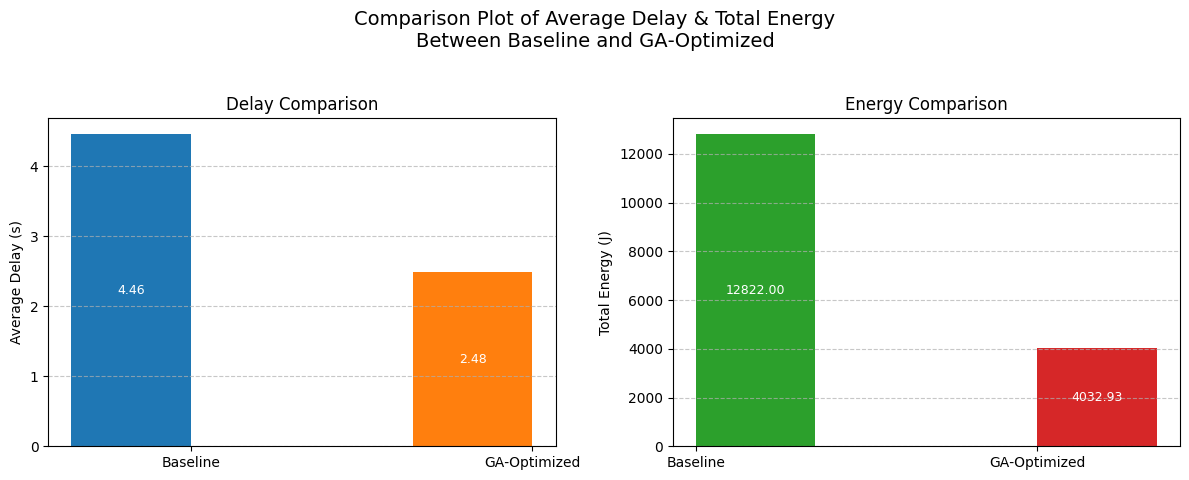

In [ ]:
# Plot perbandingan Delay & Energi (Baseline vs GA‑Optimized)
import matplotlib.pyplot as plt
import numpy as np

base_delay   = results["base_avg_delay"]
base_energy  = results["base_E_total"]
ga_delay     = results["ga_avg_delay"]
ga_energy    = results["ga_E_total"]

labels   = ["Baseline", "GA‑Optimized"]
delays   = [base_delay, ga_delay]
energies = [base_energy, ga_energy]

x = np.arange(len(labels))
width = 0.35

fig, (ax_delay, ax_energy) = plt.subplots(
    1, 2, figsize=(12, 5), sharey=False
)

bars_delay = ax_delay.bar(
    x - width/2, delays, width,
    color=["#1f77b4", "#ff7f0e"]
)
ax_delay.set_ylabel("Average Delay (s)")
ax_delay.set_title("Delay Comparison")
ax_delay.set_xticks(x)
ax_delay.set_xticklabels(labels)
ax_delay.grid(axis="y", linestyle="--", alpha=0.7)

for bar in bars_delay:
    h = bar.get_height()
    ax_delay.text(
        bar.get_x() + bar.get_width()/2,
        h * 0.5,
        f"{h:.2f}",
        ha="center", va="center",
        color="white", fontsize=9
    )

bars_energy = ax_energy.bar(
    x + width/2, energies, width,
    color=["#2ca02c", "#d62728"]
)
ax_energy.set_ylabel("Total Energy (J)")
ax_energy.set_title("Energy Comparison")
ax_energy.set_xticks(x)
ax_energy.set_xticklabels(labels)
ax_energy.grid(axis="y", linestyle="--", alpha=0.7)

for bar in bars_energy:
    h = bar.get_height()
    ax_energy.text(
        bar.get_x() + bar.get_width()/2,
        h * 0.5,
        f"{h:.2f}",
        ha="center", va="center",
        color="white", fontsize=9
    )

plt.suptitle(
    "Comparison Plot of Average Delay & Total Energy\n"
    "Between Baseline and GA‑Optimized",
    fontsize=14
)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
